In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_auc_score,
    precision_recall_curve, roc_curve
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt



import warnings
warnings.filterwarnings('ignore')

# constants
#RSEED = 10

1. Data Import

In [2]:
# import data from CSV
df = pd.read_csv("data/kickstarter_projects.csv")

In [3]:

# check import
df.head()

,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


In [4]:
df.columns

Index(['ID', 'Name', 'Category', 'Subcategory', 'Country', 'Launched',
       'Deadline', 'Goal', 'Pledged', 'Backers', 'State'],
      dtype='object')

In [5]:
# 11 Columns:
# id
# name	
# category	
# subcategory	
# country	
# launched	
# deadline	
# goal	
# pledged	
# backers	
# state
df.columns = df.columns.str.lower()
df.head()

,id,name,category,subcategory,country,launched,deadline,goal,pledged,backers,state
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


1.1 Data Check

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374853 entries, 0 to 374852
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           374853 non-null  int64 
 1   name         374853 non-null  object
 2   category     374853 non-null  object
 3   subcategory  374853 non-null  object
 4   country      374853 non-null  object
 5   launched     374853 non-null  object
 6   deadline     374853 non-null  object
 7   goal         374853 non-null  int64 
 8   pledged      374853 non-null  int64 
 9   backers      374853 non-null  int64 
 10  state        374853 non-null  object
dtypes: int64(4), object(7)
memory usage: 31.5+ MB


1.2 Statistcal Summary Check

In [7]:
df.describe()

,id,goal,pledged,backers
count,3.748530e+05,3.748530e+05,3.748530e+05,374853.000000
mean,1.074656e+09,4.586378e+04,9.121073e+03,106.690359
std,6.191377e+08,1.158778e+06,9.132054e+04,911.718520
min,5.971000e+03,0.000000e+00,0.000000e+00,0.000000
25%,5.380728e+08,2.000000e+03,3.100000e+01,2.000000
50%,1.075300e+09,5.500000e+03,6.250000e+02,12.000000
75%,1.610149e+09,1.600000e+04,4.051000e+03,57.000000
max,2.147476e+09,1.663614e+08,2.033899e+07,219382.000000


2 EDA
General Feature Exploration

In [8]:
# 2) Quick look
print("Shape:", df.shape)
display(df.head())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False))
# Rows 378661, 
# columns 11
# it shows the data types and missing values for each column. we have object and int64 data types.

Shape: (374853, 11)


,id,name,category,subcategory,country,launched,deadline,goal,pledged,backers,state
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed



Dtypes:
 id              int64
name           object
category       object
subcategory    object
country        object
launched       object
deadline       object
goal            int64
pledged         int64
backers         int64
state          object
dtype: object

Missing values:
 id             0
name           0
category       0
subcategory    0
country        0
launched       0
deadline       0
goal           0
pledged        0
backers        0
state          0
dtype: int64


In [9]:
df['state'].value_counts()

state
Failed        197611
Successful    133851
Canceled       38751
Live            2798
Suspended       1842
Name: count, dtype: int64

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374853 entries, 0 to 374852
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           374853 non-null  int64 
 1   name         374853 non-null  object
 2   category     374853 non-null  object
 3   subcategory  374853 non-null  object
 4   country      374853 non-null  object
 5   launched     374853 non-null  object
 6   deadline     374853 non-null  object
 7   goal         374853 non-null  int64 
 8   pledged      374853 non-null  int64 
 9   backers      374853 non-null  int64 
 10  state        374853 non-null  object
dtypes: int64(4), object(7)
memory usage: 31.5+ MB


# Data cleaning and feature engineering

In [11]:
# 3) Parse dates + feature engineering
# Date -> datetime
df["launched"] = pd.to_datetime(df["launched"], errors="coerce")
df["deadline"] = pd.to_datetime(df["deadline"], errors="coerce")

# Duration
df["duration_days"] = (df["deadline"] - df["launched"]).dt.total_seconds() / (24 * 3600)

df["funded_ratio"] = df["pledged"] / df["goal"]
df["is_success"] = (df["state"].astype(str).str.lower() == "successful").astype(int)
display(df[["goal", "pledged", "backers", "duration_days", "funded_ratio"]].describe())

,goal,pledged,backers,duration_days,funded_ratio
count,3.748530e+05,3.748530e+05,374853.000000,374853.000000,3.748510e+05
mean,4.586378e+04,9.121073e+03,106.690359,33.651440,inf
std,1.158778e+06,9.132054e+04,911.718520,12.814719,NaN
min,0.000000e+00,0.000000e+00,0.000000,0.005058,0.000000e+00
25%,2.000000e+03,3.100000e+01,2.000000,29.098044,4.566438e-03
50%,5.500000e+03,6.250000e+02,12.000000,29.690787,1.342857e-01
75%,1.600000e+04,4.051000e+03,57.000000,36.740370,1.065250e+00
max,1.663614e+08,2.033899e+07,219382.000000,91.962650,inf


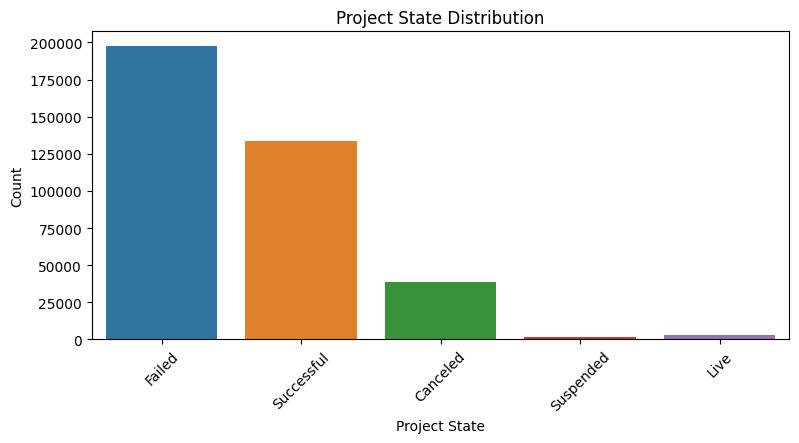

In [12]:
# A) Plotting the Project State Distribution
plt.subplots(figsize=(9,4), dpi=100)

sns.countplot(x="state",data=df)
plt.title("Project State Distribution")
plt.xlabel("Project State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [13]:
# 4) Feature engineering (best “value add” features)
df["duration_days"]    = (df["deadline"] - df["launched"]).dt.total_seconds() / (24 * 3600)     # To get the exact number of days each project ran.

# Date parts
df["launch_year"]      = df["launched"].dt.year         # This pulls/extract the year from the “Launched” date. Example: “2016-05-10” -> 2016
df["launch_month"]     = df["launched"].dt.month        # This pulls/extract the month number (1–12). Example: Oct -> 10
df["launch_dayofweek"] = df["launched"].dt.dayofweek    # This pulls/extract the day of the week. Example: Friday = 4, counting from 0 = Monday

# Funding ratio (handle goal==0 safely)
df["funded_ratio"]     = df["pledged"] / df["goal"].replace(0, np.nan)                      # Helps model understand success likelihood
df["funded_ratio"]     = df["funded_ratio"].replace([np.inf, -np.inf], np.nan).fillna(0)    # If a project had goal = 0, division would produce ∞, Replace inf -> NaN -> 0, same with pledge

# Log transforms (helps skew)
# Avoid dominance of huge values (Pledged up to millions)
# Reduce skew and long tails
df["log_goal"]         = np.log1p(df["goal"]) 
df["log_pledged"]      = np.log1p(df["pledged"])
df["log_backers"]      = np.log1p(df["backers"])    

# Simple text features from Name
df["name_length"]      = df["name"].astype(str).str.len()                 # Measures the total number of characters in the project title.
df["name_word_count"]  = df["name"].astype(str).str.split().apply(len)    # Counts how many words appear in the title.

# Target variable
df = df[df["state"].str.lower() != "live"]
df["is_success"] = (df["state"].astype(str).str.lower() == "successful").astype(int)    # Need to remove live and suspend

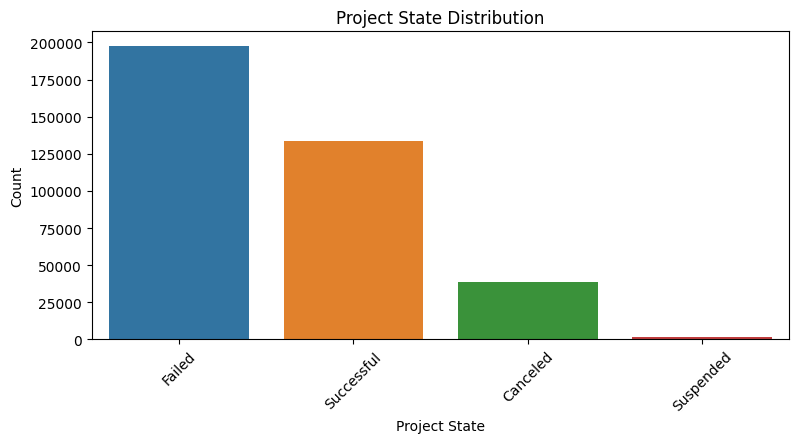

In [14]:
# A) Plotting the Project State Distribution
plt.subplots(figsize=(9,4), dpi=100)

sns.countplot(x="state",data=df)
plt.title("Project State Distribution")
plt.xlabel("Project State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [15]:
# Quick look

success_projects = df[df['state'] == 'Successful']['state'].count()     # This filters the dataframe to rows where state == “successful”,then counts how many.
fail_projects  = df[df['state'] == 'Failed']['state'].count()           # This filters the dataframe to rows where state == “failed”,then counts how many.
others_projects  = (
    df[df['state'] == 'Canceled']['state'].count() +
    df[df['state'] == 'Live']['state'].count() +
    df[df['state'] == 'Suspended']['state'].count())                    # This groups anything that isn’t clearly success or failure: "canceled", "live", "suspended"
	

print(f"Successful Projects: {success_projects}")
print(f"Failed Projects: {fail_projects}")
print(f"Other Projects: {others_projects}")

Successful Projects: 133851
Failed Projects: 197611
Other Projects: 40593


In [16]:
total=success_projects+fail_projects+others_projects
suc=success_projects/total
fail=fail_projects/total
other=others_projects/total

Text(0.5, 1.0, 'Total Success Rate')

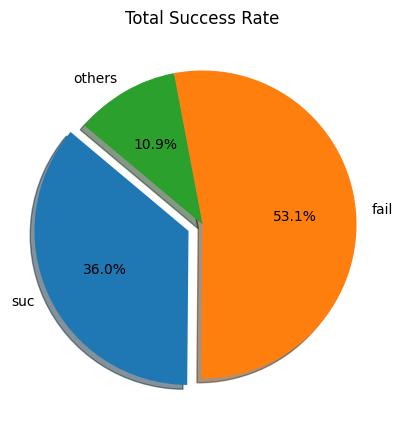

In [17]:
# B) Outcome distribution (Success vs Failed)
sizes = [suc, fail, other]
labels="suc","fail","others"
explode = (0.1, 0, 0)
plt.figure(figsize=(10,5), dpi=100)
plt.pie(sizes,labels=labels,explode=explode,
autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Total Success Rate")

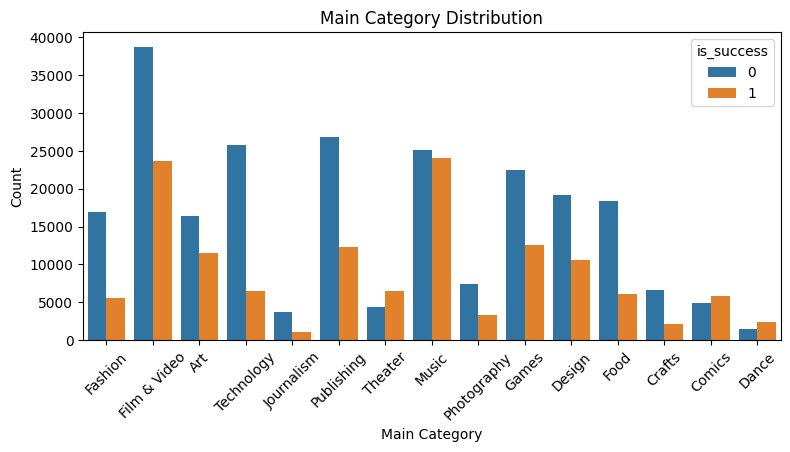

In [18]:
#Plotting the Main_category Distribution
plt.subplots(figsize=(9,4), dpi=100)
sns.countplot(x="category", hue="is_success", data=df)
plt.title("Main Category Distribution")
plt.xlabel("Main Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.subcategory.unique().coff

array(['Fashion', 'Shorts', 'Illustration', 'Software', 'Journalism',
       'Fiction', 'Theater', 'Rock', 'Photography', 'Puzzles',
       'Graphic Design', 'Film & Video', 'Publishing', 'Documentary',
       'Sculpture', 'Electronic Music', 'Nonfiction', 'Food', 'Painting',
       'Indie Rock', 'Video Games', 'Public Art', 'Product Design', 'Art',
       "Children's Books", 'Crafts', 'Jazz', 'Music', 'Comics',
       'Narrative Film', 'Tabletop Games', 'Digital Art', 'Animation',
       'Conceptual Art', 'Pop', 'Hip-Hop', 'Country & Folk',
       'Periodicals', 'Webseries', 'Performance Art', 'Technology',
       'Art Books', 'World Music', 'Knitting', 'Classical Music',
       'Poetry', 'Graphic Novels', 'Radio & Podcasts', 'Design',
       'Hardware', 'Webcomics', 'Dance', 'Translations', 'Crochet',
       'Games', 'Photo', 'Mixed Media', 'Space Exploration', 'Photobooks',
       'Musical', 'Audio', 'Community Gardens', 'R&B',
       'Fabrication Tools', 'Textiles', 'Architecture',

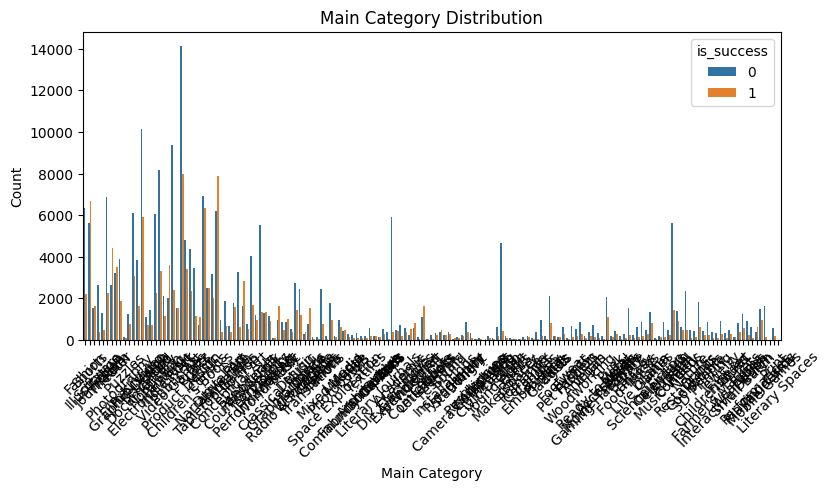

In [ ]:
# Plotting the Main_category Distribution

# I need to revisit this plot later!

# plt.subplots(figsize=(9,4), dpi=100)
# sns.countplot(x="subcategory", hue="is_success", data=df)
# plt.title("Main Category Distribution")
# plt.xlabel("Main Category")
# plt.ylabel("Count")
# plt.xticks(rotation=45)
# plt.show()

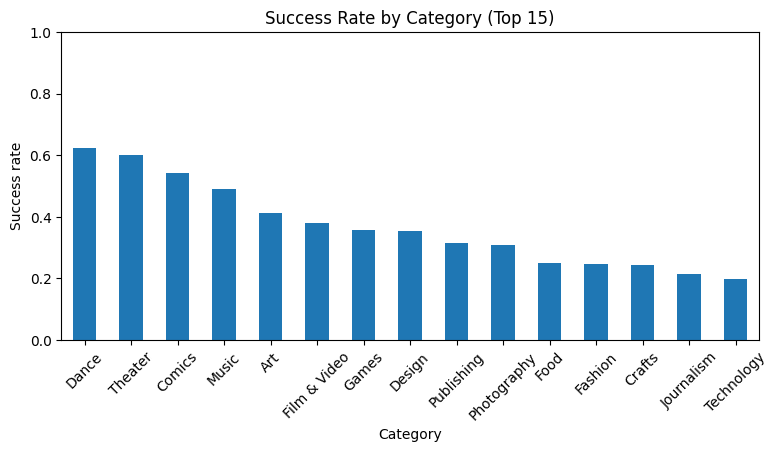

In [19]:
# C) Success rate by Category (Top 15 by volume)
top_cats = df["category"].value_counts().head(15).index
success_by_cat = (
    df[df["category"].isin(top_cats)]
    .groupby("category")["is_success"]
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(9,4), dpi=100)
success_by_cat.plot(kind="bar")
plt.title("Success Rate by Category (Top 15)")
plt.xlabel("Category")
plt.ylabel("Success rate")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

In [20]:
# plt.figure(figsize=(6,4), dpi=100)
# sns.barplot(data=df, x='category', y='subcategory', hue='is_success')
# plt.legend(loc=(1.1,0.5))

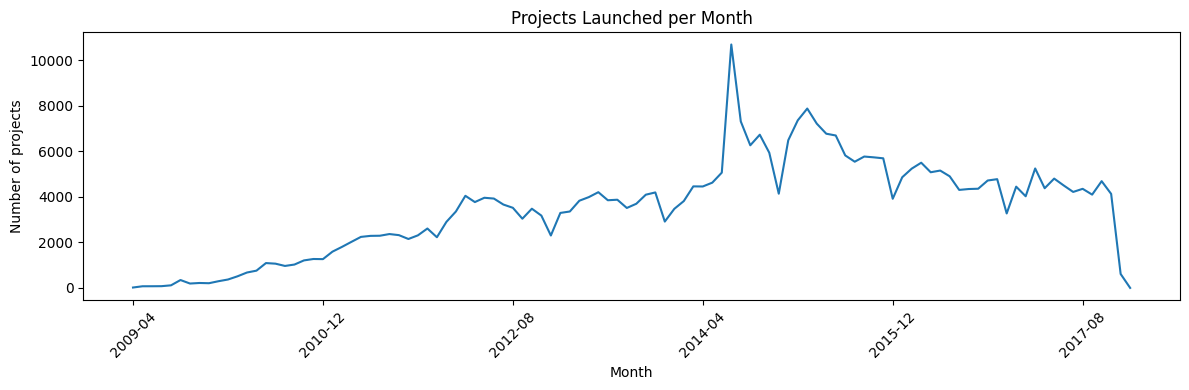

In [21]:
# D) Projects launched over time (monthly)
df["launch_ym"] = df["launched"].dt.to_period("M").astype(str)
monthly_projects = df.dropna(subset=["launched"]).groupby("launch_ym").size()

plt.figure(figsize=(12,4))
monthly_projects.plot()
plt.title("Projects Launched per Month")
plt.xlabel("Month")
plt.ylabel("Number of projects")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

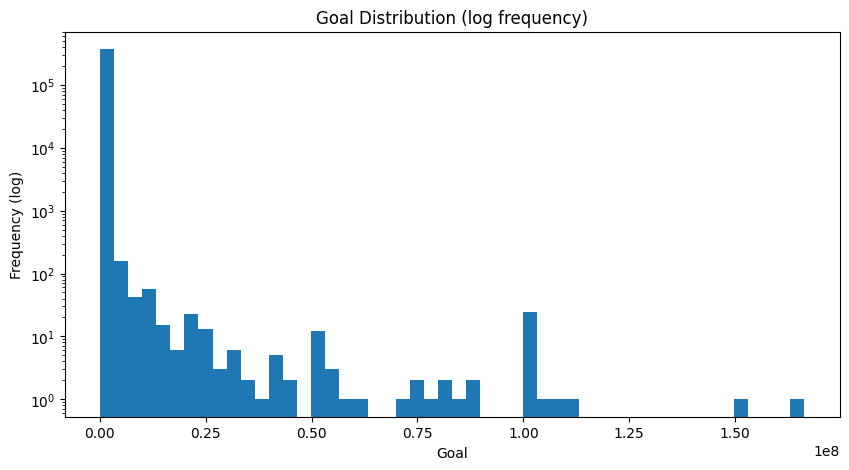

In [22]:
# E) Goal distribution (log y-scale)
plt.figure(figsize=(10,5), dpi=100)
df["goal"].replace(0, np.nan).dropna().plot(kind="hist", bins=50, log=True)
plt.title("Goal Distribution (log frequency)")
plt.xlabel("Goal")
plt.ylabel("Frequency (log)")
plt.show()

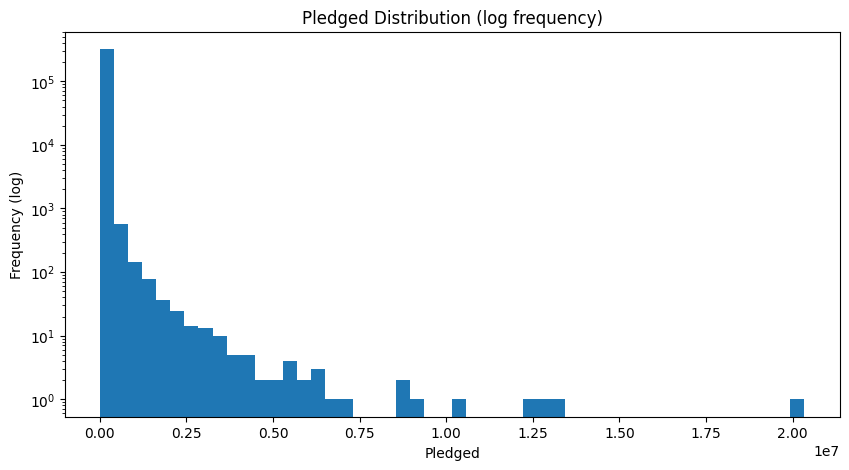

In [23]:
# F) Pledged distribution (log y-scale)
plt.figure(figsize=(10,5), dpi=100)
df["pledged"].replace(0, np.nan).dropna().plot(kind="hist", bins=50, log=True)
plt.title("Pledged Distribution (log frequency)")
plt.xlabel("Pledged")
plt.ylabel("Frequency (log)")
plt.show()


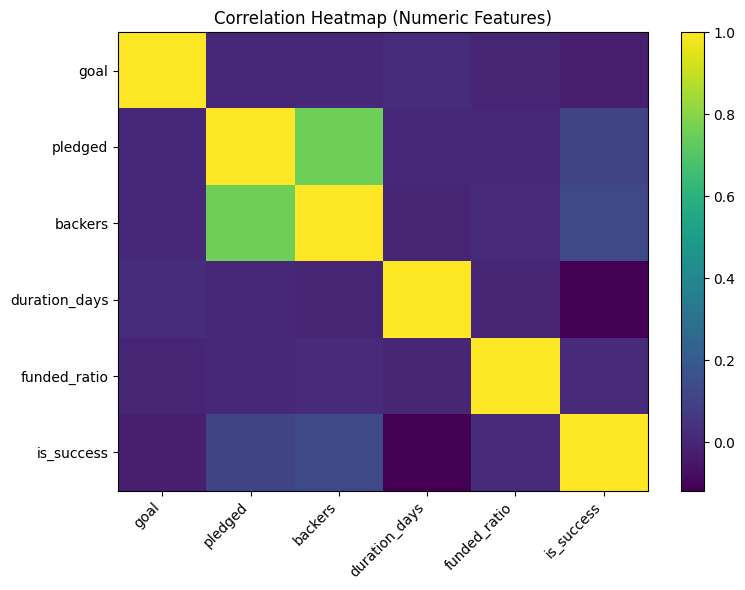

In [24]:
# G) Correlation heatmap (numeric features)
num_cols = ["goal", "pledged", "backers", "duration_days", "funded_ratio", "is_success"]
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6), dpi=100)
plt.imshow(corr, aspect="auto")
plt.title("Correlation Heatmap (Numeric Features)")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

In [25]:
# (Optional) Final “model-ready” feature table preview
# -------------------------------------------------
feature_cols = [
    "category","subcategory","country",
    "duration_days","launch_year","launch_month","launch_dayofweek",
    "log_goal","log_pledged","log_backers",
    "funded_ratio","name_length","name_word_count",
    "is_success"
]
display(df[feature_cols].head())

,category,subcategory,country,duration_days,launch_year,launch_month,launch_dayofweek,log_goal,log_pledged,log_backers,funded_ratio,name_length,name_word_count,is_success
0,Fashion,Fashion,United States,39.123056,2009,4,1,6.908755,6.439350,3.433987,0.625000,59,10,0
1,Film & Video,Shorts,United States,87.994525,2009,4,3,11.289794,3.135494,1.386294,0.000275,30,4,0
2,Art,Illustration,United States,8.088854,2009,4,4,3.044522,3.583519,1.386294,1.750000,19,3,1
3,Technology,Software,United States,79.266424,2009,4,5,4.605170,4.983607,3.258097,1.464646,28,4,1
4,Fashion,Fashion,United States,28.409271,2009,4,0,7.550135,5.961005,2.397895,0.203684,10,1,0


In [26]:
# Drop unused fields
# df = df.drop(columns=["id", "name", "launched", "deadline", "state"], axis=1)
drop_cols = ["id", "name", "launched", "deadline", "state", "launch_ym"]
drop_cols = [c for c in drop_cols if c in df.columns]
model_df = df.drop(columns=drop_cols).copy()


In [27]:
df.head()

,id,name,category,subcategory,country,launched,deadline,goal,pledged,backers,...,is_success,launch_year,launch_month,launch_dayofweek,log_goal,log_pledged,log_backers,name_length,name_word_count,launch_ym
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,...,0,2009,4,1,6.908755,6.439350,3.433987,59,10,2009-04
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,...,0,2009,4,3,11.289794,3.135494,1.386294,30,4,2009-04
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,...,1,2009,4,4,3.044522,3.583519,1.386294,19,3,2009-04
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,...,1,2009,4,5,4.605170,4.983607,3.258097,28,4,2009-04
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,...,0,2009,4,0,7.550135,5.961005,2.397895,10,1,2009-04


In [28]:
# import 
from sklearn.preprocessing import LabelEncoder

In [29]:
# Encode categorical variables
# label_cols = ["category", "subcategory", "country"]

# encoder = LabelEncoder()
# for col in label_cols:
#     df[col] = encoder.fit_transform(df[col].astype(str))
cat_cols = ["category", "subcategory", "country"]
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    encoders[col] = le



In [30]:
df.head()

,id,name,category,subcategory,country,launched,deadline,goal,pledged,backers,...,is_success,launch_year,launch_month,launch_dayofweek,log_goal,log_pledged,log_backers,name_length,name_word_count,launch_ym
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,...,0,2009,4,1,6.908755,6.439350,3.433987,59,10,2009-04
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,...,0,2009,4,3,11.289794,3.135494,1.386294,30,4,2009-04
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,...,1,2009,4,4,3.044522,3.583519,1.386294,19,3,2009-04
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,...,1,2009,4,5,4.605170,4.983607,3.258097,28,4,2009-04
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,...,0,2009,4,0,7.550135,5.961005,2.397895,10,1,2009-04


In [31]:
# 4) SELECT FEATURES FOR MODEL
# -------------------
# X = df.drop(columns=["is_success"])
# y = df["is_success"]

# Define X and y
y = model_df["is_success"]
X = model_df.drop(columns=["is_success"])

print("\nModel features:", X.columns.tolist())
print("X shape:", X.shape, " y shape:", y.shape)



Model features: ['category', 'subcategory', 'country', 'goal', 'pledged', 'backers', 'duration_days', 'funded_ratio', 'launch_year', 'launch_month', 'launch_dayofweek', 'log_goal', 'log_pledged', 'log_backers', 'name_length', 'name_word_count']
X shape: (372055, 16)  y shape: (372055,)


## Splitting data for testing 

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

## Trainining the model

# LogisticRegression

In [47]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [48]:
predictions = lr.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(classification_report(y_test, predictions))

Logistic Regression Accuracy: 0.9749
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     47641
           1       0.96      0.98      0.97     26770

    accuracy                           0.97     74411
   macro avg       0.97      0.97      0.97     74411
weighted avg       0.98      0.97      0.97     74411



# ExtraTreesClassifier

In [46]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import confusion_matrix 

# 6) FAST + ACCURATE MODEL: ExtraTreesClassifier VS RandomForest

model = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)


# 7) PREDICT + EVALUATE

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\nMODEL ACCURACY:", accuracy)
print("\nCLASSIFICATION REPORT:\n")
print(report)





MODEL ACCURACY: 0.9951754444907339

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     47641
           1       0.99      1.00      0.99     26770

    accuracy                           1.00     74411
   macro avg       0.99      1.00      0.99     74411
weighted avg       1.00      1.00      1.00     74411



In [34]:
# 6) FAST + ACCURATE MODEL: ExtraTreesClassifier VS RandomForest



models = {
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=250, n_jobs=-1, random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=250, n_jobs=-1, random_state=42
    ),
}

fitted = {}
results = []

for name, m in models.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results.append((name, acc))
    fitted[name] = m

    print("\n==============================")
    print(f"{name} — Accuracy: {acc:.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_test, preds))
    print("\nClassification report:\n", classification_report(y_test, preds))

results_df = pd.DataFrame(results, columns=["model", "accuracy"]).sort_values("accuracy", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model = fitted[best_model_name]
print("\nBest model:", best_model_name)



ExtraTrees — Accuracy: 0.9953
Confusion matrix:
 [[47296   345]
 [    4 26766]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     47641
           1       0.99      1.00      0.99     26770

    accuracy                           1.00     74411
   macro avg       0.99      1.00      0.99     74411
weighted avg       1.00      1.00      1.00     74411


RandomForest — Accuracy: 0.9976
Confusion matrix:
 [[47467   174]
 [    1 26769]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     47641
           1       0.99      1.00      1.00     26770

    accuracy                           1.00     74411
   macro avg       1.00      1.00      1.00     74411
weighted avg       1.00      1.00      1.00     74411



,model,accuracy
1,RandomForest,0.997648
0,ExtraTrees,0.995310



Best model: RandomForest


In [35]:
#training the model
# from sklearn.linear_model import LinearRegression
# reg = LinearRegression().fit(X_train, y_train)

In [36]:
# from sklearn.metrics import mean_squared_error
# y_train_pred = reg.predict(X_train)
# mse = mean_squared_error(y_train, y_train_pred)
# print(mse)

In [37]:
# y_test_pred = reg.predict(X_test)
# mse = mean_squared_error(y_test, y_test_pred)
# print(mse)

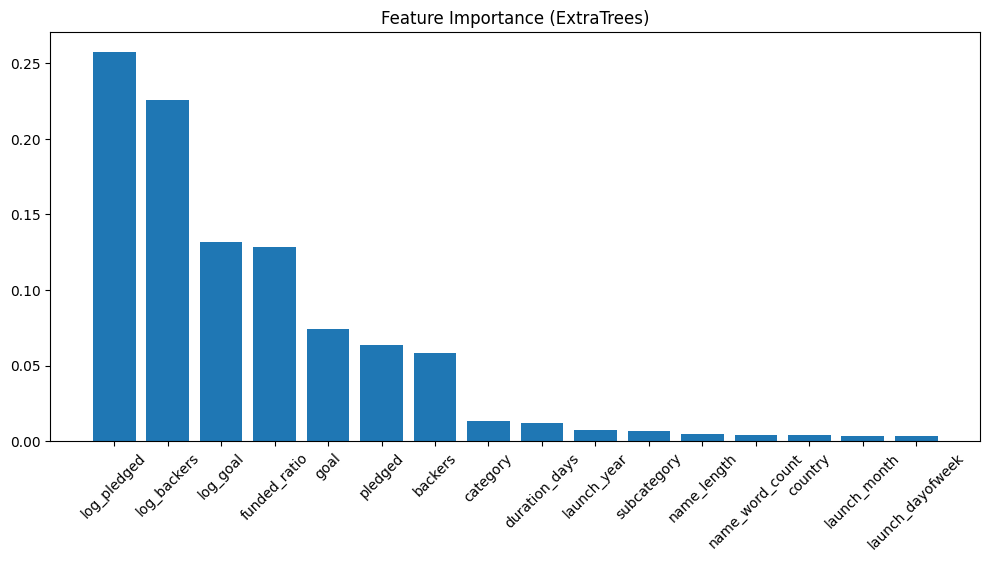

In [38]:

import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance (ExtraTrees)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

# COMPARE MODELS (ExtraTrees vs RandomForest vs XGBoost)

In [49]:
# from sklearn.ensemble import  RandomForestClassifier
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score

# models = {
#     "ExtraTrees": ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
#     "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
#     "XGBoost": XGBClassifier(
#         n_estimators=80,
#         max_depth=5,
#         learning_rate=0.1,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         eval_metric="logloss",
#         tree_method="hist",
#         random_state=42
#     )
# }

# results = {}

# for name, m in models.items():
#     m.fit(X_train, y_train)
#     preds = m.predict(X_test)
#     acc = accuracy_score(y_test, preds)
#     results[name] = acc
#     print(f"{name}: {acc}")

# results

#  HYPERPARAMETER TUNING (GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    ExtraTreesClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.994466543721653


# ROC Curve (for ExtraTrees or XGBoost)

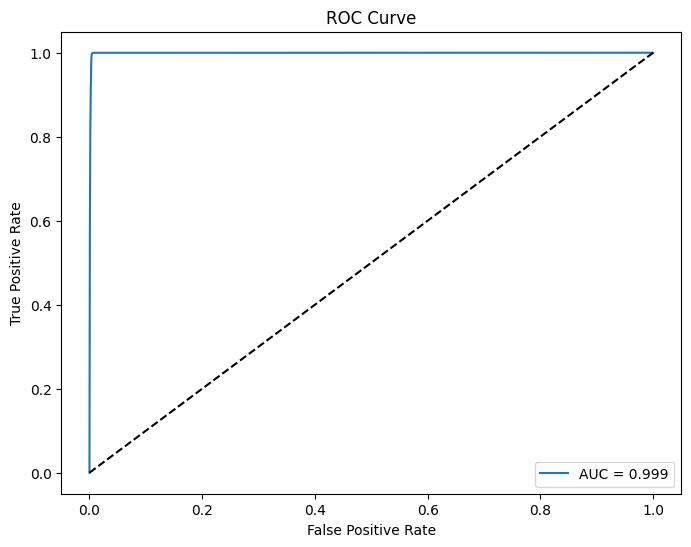

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# K-FOLD CROSS-VALIDATION (for ExtraTrees)

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    X, y,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

Cross-Validation Scores: [0.65851823 0.993845   0.99157383 0.99506793 0.9916679 ]
Mean CV Accuracy: 0.9261345768770746


In [ ]:
import pickle

with open("kickstarter_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as kickstarter_model.pkl")

Model saved as kickstarter_model.pkl


In [ ]:
with open("kickstarter_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

loaded_model.predict(X_test[:5])

array([1, 0, 0, 0, 1])